In [1]:
import pandas as pd

In [2]:
tenyear_data=pd.read_csv('/content/GoogleStock Price.csv')

In [3]:
fiveyear_data=pd.read_csv('/content/google_5yr_one.csv')

In [4]:
print(fiveyear_data.info())
print(tenyear_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1255 non-null   object
 1   Close   1256 non-null   object
 2   High    1256 non-null   object
 3   Low     1256 non-null   object
 4   Open    1256 non-null   object
 5   Volume  1256 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2645 non-null   object 
 1   Open       2645 non-null   float64
 2   High       2645 non-null   float64
 3   Low        2645 non-null   float64
 4   Close      2645 non-null   float64
 5   Adj Close  2645 non-null   float64
 6   Volume     2645 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 144.8+ KB
None


In [5]:
fiveyear_data.drop(index=0, inplace=True)

In [6]:
fiveyear_data.head()

,Date,Close,High,Low,Open,Volume
1,2020-06-04,70.3785171508789,71.72309429138843,69.96599205492319,71.4971694316438,26982000
2,2020-06-05,71.65840148925781,71.9709103787135,70.0461071028752,70.44520002096422,42642000
3,2020-06-08,72.05748748779297,72.10525562528537,70.88509140875318,70.974667107052,33878000
4,2020-06-09,72.25852966308594,73.04079279119881,71.77484210279437,71.91816171630913,33624000
5,2020-06-10,72.88652801513672,73.28810385800969,72.37198974644225,72.72778683921254,31762000


In [7]:
fiveyear_data['Date']=pd.to_datetime(fiveyear_data['Date'])
tenyear_data['Date']=pd.to_datetime(tenyear_data['Date'])

In [8]:
print(fiveyear_data.info())
print(tenyear_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 1 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   object        
 2   High    1255 non-null   object        
 3   Low     1255 non-null   object        
 4   Open    1255 non-null   object        
 5   Volume  1255 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 59.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2645 non-null   datetime64[ns]
 1   Open       2645 non-null   float64       
 2   High       2645 non-null   float64       
 3   Low        2645 non-null   float64       
 4   Close      2645 non-null   float64       
 5   Adj Close  2645 non-null   float64   

In [9]:
print(fiveyear_data['Date'].max())
print(fiveyear_data['Date'].min())
print(tenyear_data['Date'].max())
print(tenyear_data['Date'].min())

2025-06-02 00:00:00
2020-06-04 00:00:00
2023-07-06 00:00:00
2013-01-02 00:00:00


In [10]:

# Keep only 2013 up to 2020 from 10-year data
tenyear_filtered = tenyear_data[
    tenyear_data['Date'] < '2020-06-04'
]

# Combine with the complete 5-year data
combined_data = pd.concat(
    [tenyear_filtered, fiveyear_data],
    axis=0,
    ignore_index=True
)

# Sort by date
combined_data = combined_data.sort_values('Date').reset_index(drop=True)

In [11]:
combined_data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,18.099348,101550348
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,18.109859,92635272
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,18.467718,110429460
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,18.387136,66161772
4,2013-01-08,18.406906,18.425926,18.12888,18.350851,18.350851,66976956
...,...,...,...,...,...,...,...
3118,2025-05-27,170.16000366210938,173.1699981689453,170.0,172.89999389648438,NaN,37995700
3119,2025-05-28,173.16000366210938,175.27000427246094,171.91000366210938,172.36000061035156,NaN,34784000
3120,2025-05-29,174.0,174.4199981689453,170.6300048828125,171.86000061035156,NaN,29373800
3121,2025-05-30,171.35000610351562,172.2100067138672,167.44000244140625,171.74000549316406,NaN,52639900


In [12]:
print(combined_data['Date'].min())
print(combined_data['Date'].max())
print(combined_data.shape)

2013-01-02 00:00:00
2025-06-02 00:00:00
(3123, 7)


In [13]:
combined_data['Date'].nunique()

3123

In [14]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3123 non-null   datetime64[ns]
 1   Open       3123 non-null   object        
 2   High       3123 non-null   object        
 3   Low        3123 non-null   object        
 4   Close      3123 non-null   object        
 5   Adj Close  1868 non-null   float64       
 6   Volume     3123 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 170.9+ KB


In [15]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

combined_data[cols] = combined_data[cols].astype(float)

In [16]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3123 non-null   datetime64[ns]
 1   Open       3123 non-null   float64       
 2   High       3123 non-null   float64       
 3   Low        3123 non-null   float64       
 4   Close      3123 non-null   float64       
 5   Adj Close  1868 non-null   float64       
 6   Volume     3123 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 170.9 KB


In [17]:
combined_data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,18.099348,101550348.0
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,18.109859,92635272.0
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,18.467718,110429460.0
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,18.387136,66161772.0
4,2013-01-08,18.406906,18.425926,18.128880,18.350851,18.350851,66976956.0
...,...,...,...,...,...,...,...
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,NaN,37995700.0
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,NaN,34784000.0
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,NaN,29373800.0
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,NaN,52639900.0


In [18]:
combined_data.drop(columns=['Adj Close'], inplace=True)

In [19]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3123 non-null   datetime64[ns]
 1   Open    3123 non-null   float64       
 2   High    3123 non-null   float64       
 3   Low     3123 non-null   float64       
 4   Close   3123 non-null   float64       
 5   Volume  3123 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 146.5 KB


In [20]:
df=combined_data.copy()

In [21]:
df


,Date,Open,High,Low,Close,Volume
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,101550348.0
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,92635272.0
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,110429460.0
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,66161772.0
4,2013-01-08,18.406906,18.425926,18.128880,18.350851,66976956.0
...,...,...,...,...,...,...
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,37995700.0
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,34784000.0
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,29373800.0
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,52639900.0


# Questions
Are there duplicate dates?

Are dates sorted?

Are there missing trading days?

Are Open/High/Low/Close numeric?

Are there impossible OHLC relationships?

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3123 entries, 0 to 3122
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3123 non-null   datetime64[ns]
 1   Open    3123 non-null   float64       
 2   High    3123 non-null   float64       
 3   Low     3123 non-null   float64       
 4   Close   3123 non-null   float64       
 5   Volume  3123 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 146.5 KB


In [23]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,3123,3123.000000,3123.000000,3123.000000,3123.000000,3.123000e+03
mean,2019-03-16 01:20:41.498559232,76.168555,76.981773,75.377539,76.194167,4.055180e+07
min,2013-01-02 00:00:00,17.634134,17.651152,17.405405,17.589338,9.312000e+06
25%,2016-02-08 12:00:00,36.747000,36.961500,36.369249,36.609001,2.589700e+07
50%,2019-03-18 00:00:00,58.555000,59.070000,57.982498,58.540001,3.288400e+07
75%,2022-04-20 12:00:00,115.420181,117.220078,114.168167,115.934971,4.629883e+07
max,2025-06-02 00:00:00,203.156027,206.811821,202.576693,206.142593,4.621933e+08
std,NaN,47.816430,48.391726,47.279263,47.832818,2.537867e+07


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [26]:
df['Date'].is_monotonic_increasing

True

In [27]:
df['Date'].nunique()


3123

In [28]:
len(df)

3123

In [29]:
(df['High'] < df['Low']).sum()

np.int64(0)

In [30]:
(df['High'] < df['Open']).sum()

np.int64(0)

In [31]:
(df['High'] < df['Close']).sum()

np.int64(0)

In [32]:
(df['Low'] > df['Close']).sum()

np.int64(0)

In [33]:

(df['Low'] > df['Open']).sum()

np.int64(0)

In [34]:
df['Daily_Return'] = df['Close'].pct_change() ## percentage of daily daily retrun

In [35]:
df

,Date,Open,High,Low,Close,Volume,Daily_Return
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,101550348.0,NaN
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,92635272.0,0.000581
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,110429460.0,0.019760
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,66161772.0,-0.004363
4,2013-01-08,18.406906,18.425926,18.128880,18.350851,66976956.0,-0.001973
...,...,...,...,...,...,...,...
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,37995700.0,0.026295
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,34784000.0,-0.003123
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,29373800.0,-0.002901
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,52639900.0,-0.000698


In [36]:
import numpy as np

df['Log_Return'] = np.log(
    df['Close'] / df['Close'].shift(1)  # Positive value → stock increased
                                        # Negative value → stock decreased
    )


# the percentage change between today’s and yesterday’s closing price, in log form.

In [37]:
df

,Date,Open,High,Low,Close,Volume,Daily_Return,Log_Return
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,101550348.0,NaN,NaN
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,92635272.0,0.000581,0.000581
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,110429460.0,0.019760,0.019568
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,66161772.0,-0.004363,-0.004373
4,2013-01-08,18.406906,18.425926,18.128880,18.350851,66976956.0,-0.001973,-0.001975
...,...,...,...,...,...,...,...,...
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,37995700.0,0.026295,0.025956
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,34784000.0,-0.003123,-0.003128
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,29373800.0,-0.002901,-0.002905
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,52639900.0,-0.000698,-0.000698


In [38]:
## daily price range:

df['Daily_Range']=(df['High']- df['Low'])  /  df['Close']

In [39]:
df

,Date,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Daily_Range
0,2013-01-02,18.003504,18.193193,17.931683,18.099348,101550348.0,NaN,NaN,0.014449
1,2013-01-03,18.141392,18.316566,18.036036,18.109859,92635272.0,0.000581,0.000581,0.015491
2,2013-01-04,18.251753,18.555305,18.210211,18.467718,110429460.0,0.019760,0.019568,0.018686
3,2013-01-07,18.404655,18.503002,18.282784,18.387136,66161772.0,-0.004363,-0.004373,0.011977
4,2013-01-08,18.406906,18.425926,18.128880,18.350851,66976956.0,-0.001973,-0.001975,0.016187
...,...,...,...,...,...,...,...,...,...
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,37995700.0,0.026295,0.025956,0.018334
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,34784000.0,-0.003123,-0.003128,0.019494
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,29373800.0,-0.002901,-0.002905,0.022053
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,52639900.0,-0.000698,-0.000698,0.027775


In [40]:
## Google experience the largest intraday movements? top 10 days


df.nlargest(10, 'Daily_Range')[
    ['Date', 'High', 'Low', 'Close', 'Daily_Range']
]

,Date,High,Low,Close,Daily_Range
3105,2025-05-07,165.000000,147.839996,151.380005,0.113357
3086,2025-04-09,159.550003,143.910004,158.710007,0.098545
1467,2018-10-29,55.441502,50.360001,51.736500,0.098219
1815,2020-03-19,57.630501,52.777500,55.583500,0.087310
1811,2020-03-13,60.720001,55.614498,60.713501,0.084092
3084,2025-04-07,152.850006,140.529999,146.750000,0.083952
777,2016-02-03,39.571499,36.813000,37.469002,0.073621
1812,2020-03-16,57.273499,53.354000,53.650002,0.073057
1810,2020-03-12,59.437500,55.423500,55.577499,0.072223
1816,2020-03-20,56.924000,53.105000,53.410500,0.071503


Rolling Volatility

Use 20-day and 60-day volatility.

In [41]:
df['Volatility_20'] = (
    df['Log_Return']
    .rolling(20)
    .std()
    * np.sqrt(252)
)

df['Volatility_60'] = (
    df['Log_Return']
    .rolling(60)
    .std()
    * np.sqrt(252)
)

In [42]:
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

In [43]:
df.tail()

,Date,Open,High,Low,Close,Volume,Daily_Return,Log_Return,Daily_Range,Volatility_20,Volatility_60,MA_20,MA_50,MA_200
3118,2025-05-27,170.160004,173.169998,170.000000,172.899994,37995700.0,0.026295,0.025956,0.018334,0.390784,0.414078,162.7485,159.437601,170.798961
3119,2025-05-28,173.160004,175.270004,171.910004,172.360001,34784000.0,-0.003123,-0.003128,0.019494,0.390856,0.412116,163.3585,159.599001,170.853541
3120,2025-05-29,174.000000,174.419998,170.630005,171.860001,29373800.0,-0.002901,-0.002905,0.022053,0.389034,0.409465,164.0115,159.822801,170.897450
3121,2025-05-30,171.350006,172.210007,167.440002,171.740005,52639900.0,-0.000698,-0.000698,0.027775,0.386849,0.408689,164.5335,159.979801,170.947634
3122,2025-06-02,167.839996,169.869995,167.389999,169.029999,38532600.0,-0.015780,-0.015906,0.014672,0.388950,0.409905,164.7835,160.104401,170.974952


In [44]:
df['Signal'] = np.where(
    df['MA_50'] > df['MA_200'],
    1,
    0
)

In [45]:
df['Signal'].value_counts()

,count
Signal,
1,2268
0,855


In [46]:
## Drawdown Analysis


In [47]:
df['Running_Max'] = df['Close'].cummax()

df['Drawdown'] = (
    df['Close'] - df['Running_Max']
) / df['Running_Max']

In [48]:
round(df['Drawdown'].min()*100,2 )

## What was Google's maximum drawdown?


-44.32

In [49]:
df.nsmallest(
    10,
    'Drawdown'
)[['Date', 'Close', 'Drawdown']]  ## Find the worst periods:

,Date,Close,Drawdown
2478,2022-11-03,83.033020,-0.443201
2515,2022-12-28,85.610695,-0.425915
2520,2023-01-05,85.789841,-0.424714
2479,2022-11-04,86.168037,-0.422178
2477,2022-11-02,86.556183,-0.419575
2482,2022-11-09,86.904518,-0.417239
2521,2023-01-06,86.924423,-0.417106
2514,2022-12-27,86.974174,-0.416772
2512,2022-12-22,87.342422,-0.414303
2522,2023-01-09,87.601181,-0.412568


In [50]:
max_drawdown = df['Drawdown'].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -44.32%


In [51]:

## Which years experienced the highest downside risk?

df['Year'] = df['Date'].dt.year

yearly_drawdown = (
    df.groupby('Year')['Drawdown']
      .min()
      .sort_values()
)

print(yearly_drawdown)

Year
2022   -0.443201
2023   -0.424714
2020   -0.308708
2025   -0.298059
2018   -0.234018
2024   -0.221376
2019   -0.202279
2015   -0.186076
2014   -0.184275
2016   -0.142098
2013   -0.086680
2017   -0.084459
2021   -0.080455
Name: Drawdown, dtype: float64


In [52]:
yearly_drawdown.head(5)   # Top 5 worst years

,Drawdown
Year,
2022,-0.443201
2023,-0.424714
2020,-0.308708
2025,-0.298059
2018,-0.234018


In [53]:
 ### Yearly Performance

In [54]:
df['Year'] = df['Date'].dt.year

In [55]:
yearly = df.groupby('Year').agg(
    Start=('Close', 'first'),
    End=('Close', 'last'),
    High=('High', 'max'),
    Low=('Low', 'min')
)

yearly['Return'] = (
    yearly['End'] / yearly['Start'] - 1
) * 100

In [56]:
yearly

,Start,End,High,Low,Return
Year,,,,,
2013,18.099348,28.045795,28.053053,17.405405,54.954727
2014,27.855856,26.533001,30.752752,24.859501,-4.748930
2015,26.477501,38.900501,39.934502,24.545500,46.919082
2016,37.972000,39.622501,41.950001,33.632999,4.346627
2017,40.400501,52.669998,54.324501,39.844501,30.369665
2018,53.660500,52.248001,64.571999,48.882999,-2.632287
2019,52.734001,66.969498,68.352501,51.118500,26.994911
2020,68.433998,87.215034,91.752825,50.443501,27.444015
2021,85.895836,144.162781,150.248182,84.401482,67.834423


In [57]:


## Which year was Google's best performing year?

answer = yearly.nlargest(1, 'Return')

print(answer)




          Start         End        High        Low     Return
Year                                                         
2021  85.895836  144.162781  150.248182  84.401482  67.834423


In [58]:
## Which year had the worst return?

answer = yearly.nsmallest(1, 'Return')

print(answer)

          Start        End        High        Low     Return
Year                                                        
2022  144.30159  87.810188  150.825426  82.943444 -39.148149


In [59]:
# Monthly Seasonality

df['Month'] = df['Date'].dt.month

monthly_returns = (
    df.groupby(['Year', 'Month'])['Close']
    .agg(['first', 'last'])
)

monthly_returns['Return'] = (
    monthly_returns['last'] /
    monthly_returns['first'] - 1
)

In [60]:
monthly_returns

first        last    Return
Year Month                                  
2013 1       18.099348   18.911161  0.044853
     2       19.409409   20.050051  0.033007
     3       20.174925   19.874624 -0.014885
     4       20.049801   20.634886  0.029182
     5       20.531281   21.802301  0.061907
...                ...         ...       ...
2025 2      200.998505  170.084106 -0.153804
     3      166.817871  154.639999 -0.073001
     4      157.070007  158.800003  0.011014
     5      161.300003  171.740005  0.064724
     6      169.029999  169.029999  0.000000

[150 rows x 3 columns]

In [61]:
monthly_returns.groupby('Month')['Return'].mean()

,Return
Month,
1,0.042024
2,-0.019430
3,-0.005060
4,0.015527
5,0.042515
6,-0.004746
7,0.063382
8,0.000779
9,-0.015939


In [62]:


# Is January historically stronger?
YES
# Is September weaker?
YES

NameError: name 'YES' is not defined

In [63]:
# Which month has the highest average return?
monthly_returns_max=monthly_returns.groupby('Month')['Return'].mean()
monthly_returns_max.nlargest(1)

,Return
Month,
7,0.063382


In [ ]:
df

In [ ]:
df['Volatility_20'].std() * np.sqrt(252)

In [64]:
monthly_volatility = (
    df.groupby(df['Date'].dt.to_period('M'))['Volatility_20']
    .mean()
)

highest_volatility_month = monthly_volatility.idxmax()
highest_volatility_value = monthly_volatility.max()

print("Highest Volatility Month:", highest_volatility_month)
print("Volatility:", highest_volatility_value)

Highest Volatility Month: 2020-03
Volatility: 0.6678834733289546


In [ ]:
# Day-of-Week Analysis

In [65]:
df['DayOfWeek'] = df['Date'].dt.day_name()



In [66]:
df.groupby('DayOfWeek')['Daily_Return'].agg(
    ['mean', 'std', 'min', 'max']
).reset_index()

,DayOfWeek,mean,std,min,max
0,Friday,0.000739,0.019464,-0.056323,0.162584
1,Monday,0.000175,0.016792,-0.116341,0.082813
2,Thursday,0.000310,0.016370,-0.082046,0.075813
3,Tuesday,0.001351,0.015288,-0.075019,0.071984
4,Wednesday,0.001698,0.019298,-0.095094,0.096821


In [67]:
df['Daily_Return'].describe()

,Daily_Return
count,3122.000000
mean,0.000869
std,0.017524
min,-0.116341
25%,-0.007521
50%,0.001002
75%,0.009439
max,0.162584


In [68]:
df['Daily_Return'].skew()


np.float64(0.3593330643149346)

In [69]:
df['Daily_Return'].kurt()

np.float64(7.553626003975765)

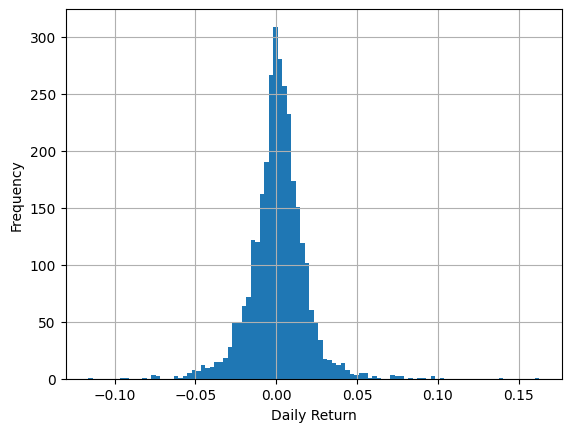

In [70]:
import matplotlib.pyplot as plt

df['Daily_Return'].hist(bins=100)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df